# Tourist attraction recommendations


Installasi

In [17]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from haversine import haversine, Unit
from sentence_transformers import SentenceTransformer
import json
import ast

# INSTALLATION AND IMPORT DEPENDENCIES
# Note: !pip install is usually run once; I will keep the imports clean here.
print("Dependencies imported successfully.")

Dependencies imported successfully.


## Data Preprocessing and Feature Fusion Results
*This section documents data transformation from raw JSON format, cleaning, normalization using RobustScaler, and Feature Fusion between semantic vectors (SBERT) and numerical features.*

## 1. Data Preprocessing
Data cleaning, handling missing values, and extracting information from JSON/String formats.

In [18]:
# LOAD & CLEANING DATA
# Load dataset
df = pd.read_csv('Tourism_Data.csv')

# Remove duplicates based on 'title'
df = df.drop_duplicates(subset=['title'])

# Remove rows with missing 'latitude' or 'longitude'
df = df.dropna(subset=['latitude', 'longitude'])

# Ensure 'latitude' and 'longitude' are float types
df['latitude'] = df['latitude'].astype(float)
df['longitude'] = df['longitude'].astype(float)

# Fill missing values in specific columns
df['title'] = df['title'].fillna('')
df['category'] = df['category'].fillna('')
df['review_rating'] = df['review_rating'].fillna('N/A')

df = df.reset_index(drop=True)
print(f"Data cleaning complete. Total rows: {len(df)}")

Data cleaning complete. Total rows: 5509


### RobustScaler Normalization
This section demonstrates that `RobustScaler` successfully centers the data on the median and uses the Interquartile Range (IQR), ensuring that Latitude, Longitude, and Rating features have a uniform scale despite extreme outliers.

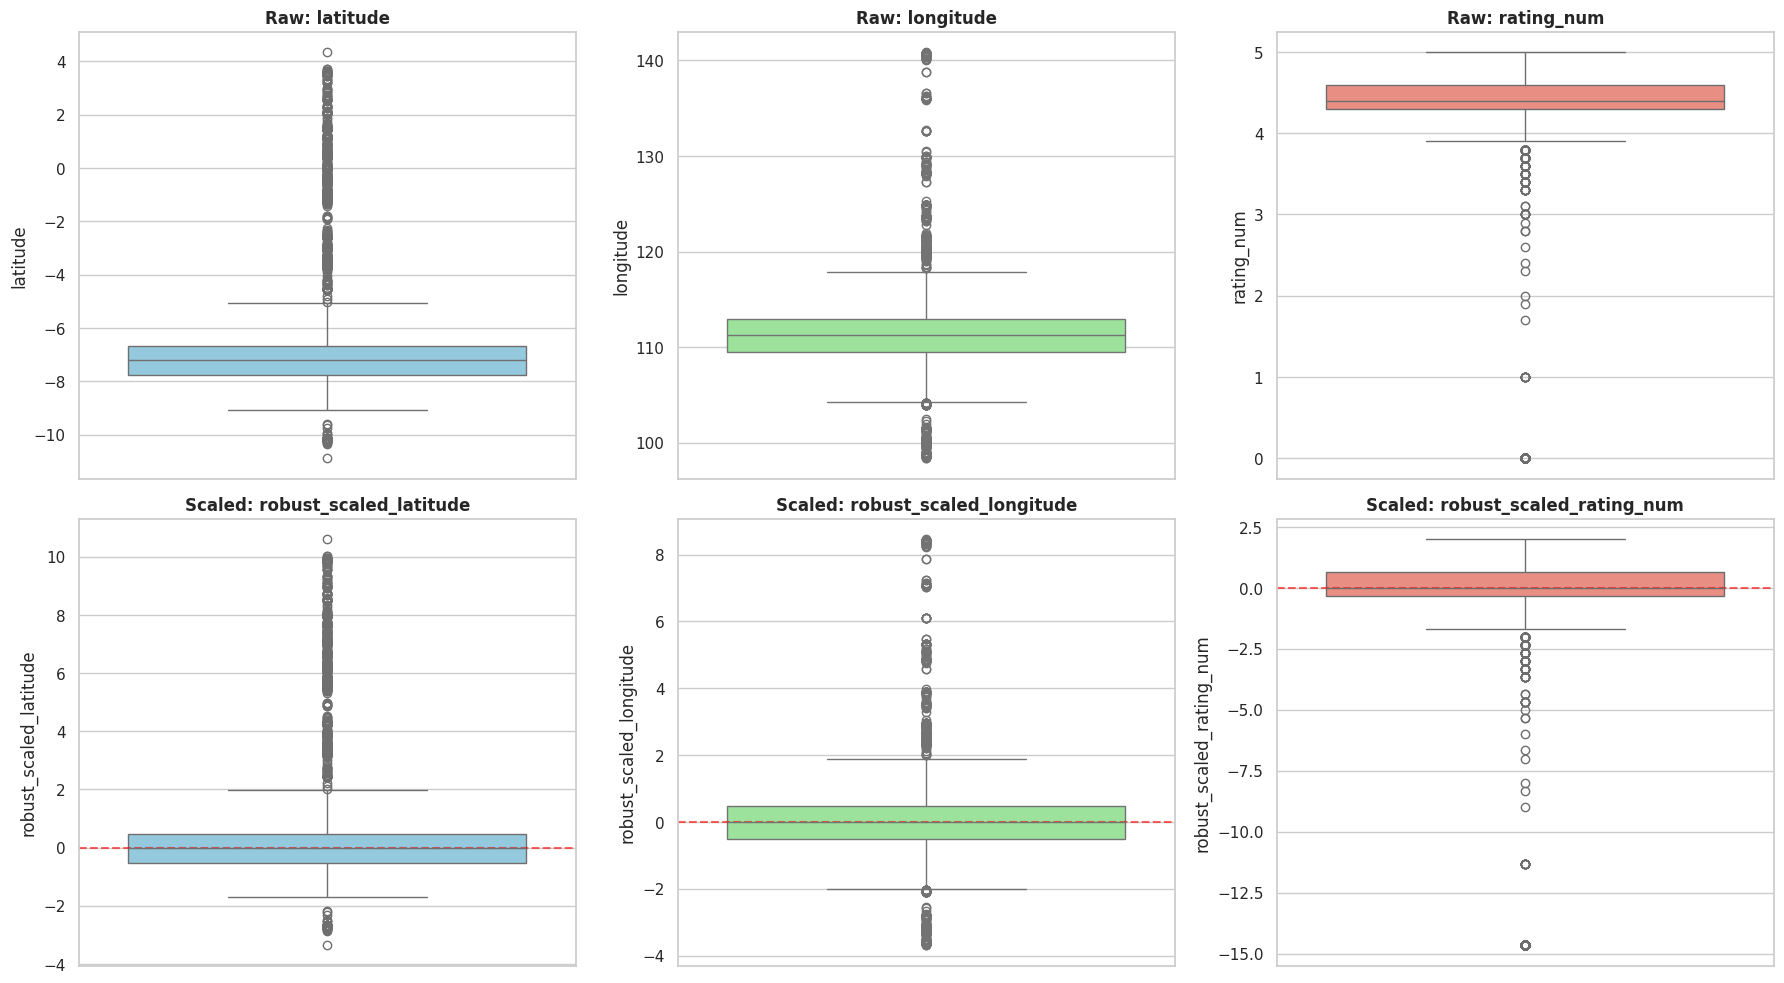


=== TABLE 1: RAW DATA STATISTICS (BEFORE SCALING) ===


,latitude,longitude,rating_num
count,5509.000000,5509.000000,5509.000000
mean,-6.252369,111.819643,4.325885
std,2.818809,5.774170,0.716920
min,-10.889968,98.382904,0.000000
25%,-7.785725,109.457235,4.300000
50%,-7.221812,111.284144,4.400000
75%,-6.694080,112.952438,4.600000
max,4.351794,140.864349,5.000000



=== TABLE 2: ROBUST SCALED STATISTICS (AFTER SCALING) ===


,robust_scaled_latitude,robust_scaled_longitude,robust_scaled_rating_num
count,5509.000000,5509.000000,5509.000000
mean,0.888057,0.153210,-0.247050
std,2.582166,1.652027,2.389733
min,-3.360210,-3.691128,-14.666667
25%,-0.516572,-0.522690,-0.333333
50%,0.000000,0.000000,0.000000
75%,0.483428,0.477310,0.666667
max,10.601987,8.463086,2.000000



Note: Median (50%) in Table 2 is now centered at 0.0000.


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# 1. Prepare Numerical Data & Scaling
df['rating_num'] = pd.to_numeric(df['review_rating'], errors='coerce').fillna(0)
original_cols = ['latitude', 'longitude', 'rating_num']
scaler = RobustScaler()
scaled_names = [f'robust_scaled_{col}' for col in original_cols]
df[scaled_names] = scaler.fit_transform(df[original_cols])

# 2. Boxplot Visualization
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Raw Data
for i, col in enumerate(original_cols):
    sns.boxplot(y=df[col], ax=axes[0, i], color=['skyblue', 'lightgreen', 'salmon'][i])
    axes[0, i].set_title(f'Raw: {col}', fontweight='bold')

# Row 2: Robust Scaled
for i, col in enumerate(scaled_names):
    sns.boxplot(y=df[col], ax=axes[1, i], color=['skyblue', 'lightgreen', 'salmon'][i])
    axes[1, i].set_title(f'Scaled: {col}', fontweight='bold')
    axes[1, i].axhline(0, color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Display Statistics
print("\n=== TABLE 1: RAW DATA STATISTICS (BEFORE SCALING) ===")
display(df[original_cols].describe())

print("\n=== TABLE 2: ROBUST SCALED STATISTICS (AFTER SCALING) ===")
display(df[scaled_names].describe())

print("\nNote: Median (50%) in Table 2 is now centered at 0.0000.")

In [4]:
import pandas as pd

# Memeriksa struktur kolom Collaborative Filtering
df_check = pd.read_csv('wisata-data.csv')
print("Kolom yang tersedia:", df_check.columns.tolist())
display(df_check.head())

Kolom yang tersedia: ['input_id', 'link', 'title', 'category', 'address', 'open_hours', 'popular_times', 'website', 'phone', 'plus_code', 'review_count', 'review_rating', 'reviews_per_rating', 'latitude', 'longitude', 'cid', 'status', 'descriptions', 'reviews_link', 'thumbnail', 'timezone', 'price_range', 'data_id', 'place_id', 'images', 'reservations', 'order_online', 'menu', 'owner', 'complete_address', 'about', 'user_reviews', 'user_reviews_extended', 'emails']


,input_id,link,title,category,address,open_hours,popular_times,website,phone,plus_code,...,images,reservations,order_online,menu,owner,complete_address,about,user_reviews,user_reviews_extended,emails
0,e06f118f-cb04-4647-a212-2e9ad9a5e068,https://www.google.com/maps/place/Alun+-+Alun+...,Alun - Alun Surabaya,Taman|Landmark,"Jl. Gubernur Suryo, Embong Kaliasin, Kec. Gent...",{},{},NaN,NaN,"PPPW+H4 Embong Kaliasin, Surabaya, Jawa Timur,...",...,"[{""title"":""Semua"",""image"":""https://lh3.googleu...",NaN,NaN,"{""link"":"""",""source"":""""}","{""id"":"""",""name"":""Alun - Alun Surabaya (Pemilik...","{""borough"":""Embong Kaliasin, Kecamatan Genteng...","[{""id"":""accessibility"",""name"":""Aksesibilitas"",...","[{""Name"":""Rivani Rahmadani"",""ProfilePicture"":""...",NaN,NaN
1,e06f118f-cb04-4647-a212-2e9ad9a5e068,https://www.google.com/maps/place/Hutan+Bambu+...,Hutan Bambu Keputih Surabaya,Hutan|Taman|Wisata Religi,"PR42+8MH Hutan Bambu Keputih Surabaya, Jl. Ray...","{""Jumat"":[""Buka 24 jam""],""Kamis"":[""Buka 24 jam...","{""Friday"":{""0"":35,""1"":21,""10"":56,""11"":53,""12"":...",NaN,NaN,NaN,...,"[{""title"":""Semua"",""image"":""https://lh3.googleu...",NaN,NaN,"{""link"":"""",""source"":""""}","{""id"":"""",""name"":""Hutan Bambu Keputih Surabaya ...","{""borough"":""Keputih, Kecamatan Sukolilo"",""stre...","[{""id"":""accessibility"",""name"":""Aksesibilitas"",...","[{""Name"":""Astry Handayani"",""ProfilePicture"":""h...",NaN,NaN
2,e06f118f-cb04-4647-a212-2e9ad9a5e068,https://www.google.com/maps/place/Taman+Air+Ma...,Taman Air Mancur Pelangi,Landmark|Taman,"QQ7W+P6C Taman Air Mancur Pelangi, Kenjeran, K...","{""Jumat"":[""Buka 24 jam""],""Kamis"":[""Buka 24 jam...","{""Friday"":{""0"":4,""1"":3,""10"":14,""11"":15,""12"":18...",NaN,NaN,NaN,...,"[{""title"":""Semua"",""image"":""https://lh3.googleu...",NaN,NaN,"{""link"":"""",""source"":""""}","{""id"":"""",""name"":""Taman Air Mancur Pelangi (Pem...","{""borough"":""Kenjeran, Kecamatan Bulak"",""street...","[{""id"":""accessibility"",""name"":""Aksesibilitas"",...","[{""Name"":""Akhmad Yusuf"",""ProfilePicture"":""http...",NaN,NaN
3,e06f118f-cb04-4647-a212-2e9ad9a5e068,https://www.google.com/maps/place/Taman+Apsari...,Taman Apsari,Taman,"Jl. Taman Apsari No.63, Embong Kaliasin, Kec. ...","{""Jumat"":[""Buka 24 jam""],""Kamis"":[""Buka 24 jam...","{""Friday"":{""0"":39,""1"":24,""10"":11,""11"":12,""12"":...",NaN,NaN,"PPPV+F4 Embong Kaliasin, Surabaya, Jawa Timur,...",...,"[{""title"":""Semua"",""image"":""https://lh3.googleu...",NaN,NaN,"{""link"":"""",""source"":""""}","{""id"":"""",""name"":""Taman Apsari (Pemilik)"",""link...","{""borough"":""Embong Kaliasin, Kecamatan Genteng...","[{""id"":""highlights"",""name"":""Keunggulan"",""optio...","[{""Name"":""Aditya Galih"",""ProfilePicture"":""http...",NaN,NaN
4,e06f118f-cb04-4647-a212-2e9ad9a5e068,https://www.google.com/maps/place/Taman+Surobo...,Taman Suroboyo,Taman,"QQFQ+V6H Taman Suroboyo, Jl. Pantai Kenjeran, ...","{""Jumat"":[""Buka 24 jam""],""Kamis"":[""Buka 24 jam...","{""Friday"":{""0"":20,""1"":12,""10"":19,""11"":18,""12"":...",NaN,NaN,NaN,...,"[{""title"":""Semua"",""image"":""https://lh3.googleu...",NaN,NaN,"{""link"":"""",""source"":""""}","{""id"":"""",""name"":""Taman Suroboyo (Pemilik)"",""li...","{""borough"":""Kedung Cowek, Kecamatan Bulak"",""st...","[{""id"":""highlights"",""name"":""Keunggulan"",""optio...","[{""Name"":""Imronah"",""ProfilePicture"":""https://l...",NaN,NaN


### Checking User Data

In [23]:
# Checking for data in 'user_reviews' or 'user_reviews_extended'
print("Number of non-null data in 'user_reviews':", df['user_reviews'].count())
print("Number of non-null data in 'user_reviews_extended':", df['user_reviews_extended'].count())

# Previewing available reviews
if df['user_reviews'].count() > 0:
    sample = df['user_reviews'].dropna().iloc[0]
    print("\n'user_reviews' data sample:")
    print(sample[:500])
else:
    print("\nBoth review columns are empty. No user interaction data for Collaborative Filtering.")

Number of non-null data in 'user_reviews': 5509
Number of non-null data in 'user_reviews_extended': 0

'user_reviews' data sample:
[{"Name":"Rivani Rahmadani","ProfilePicture":"https://lh3.googleusercontent.com/a-/ALV-UjV2FxsslM0F8efZgLpznPB6ReC16IvZah2Lb1qcpsoMg7dCXgA=s120-c-rp-mo-ba6-br100","Rating":5,"Description":"Tempat yang cocok untuk menghabiskan waktu santai di tengah Kota Surabaya, bisa untuk lari pagi atau sekedar nongkrong menikmati suasana Kota Surabaya yang ramai. Tempatnya bersih, tertata dengan baik dan vibes nya menyenangkan. Cukup ramah untuk pejalan kaki.\n\n#LetsGuide #VanieOnVacation #SurabayaOnGoogleMa


### Extracting User-Item Interaction Data
Parsing the raw review data into a structured format for collaborative filtering analysis.

In [24]:
import json
import ast

# Extracting User-Item interaction data from user_reviews column
user_interactions = []

for idx, row in df.iterrows():
    reviews_raw = row['user_reviews']
    place_name = row['title']

    if pd.notna(reviews_raw):
        try:
            # Parsing JSON string to list of dictionaries
            reviews_list = json.loads(reviews_raw) if isinstance(reviews_raw, str) else reviews_raw
            if not isinstance(reviews_list, list):
                reviews_list = ast.literal_eval(reviews_raw)

            for rev in reviews_list:
                if 'Name' in rev and 'Rating' in rev:
                    user_interactions.append({
                        'user_name': rev['Name'],
                        'place_title': place_name,
                        'rating': rev['Rating']
                    })
        except:
            continue

# Creating a specific DataFrame for Collaborative Filtering
df_cf = pd.DataFrame(user_interactions)
print(f"Successfully extracted {len(df_cf)} user interactions.")
print("\nInteraction data sample:")
display(df_cf.head())

Successfully extracted 40851 user interactions.

Interaction data sample:


,user_name,place_title,rating
0,Rivani Rahmadani,Alun - Alun Surabaya,5
1,Dorry Indra,Alun - Alun Surabaya,5
2,Iffah Ipeh,Alun - Alun Surabaya,5
3,Aditya Galih,Alun - Alun Surabaya,5
4,Muzan K.,Alun - Alun Surabaya,4


### Building Interaction Matrix for Collaborative Filtering
Constructing a matrix where rows represent Users and columns represent Tourist Attraction Titles.

In [20]:
# Create Pivot Table (User-Item Matrix)
# Filter active users with more than 1 review for better pattern recognition
user_counts = df_cf['user_name'].value_counts()
active_users = user_counts[user_counts > 1].index
df_cf_filtered = df_cf[df_cf['user_name'].isin(active_users)]

pivot_matrix = df_cf_filtered.pivot_table(index='user_name', columns='place_title', values='rating').fillna(0)

# Calculate Item-Item Similarity using Cosine Similarity
item_sim_matrix = cosine_similarity(pivot_matrix.T)
item_sim_df = pd.DataFrame(item_sim_matrix, index=pivot_matrix.columns, columns=pivot_matrix.columns)

print("Item Similarity Matrix created successfully!")
display(item_sim_df.head())

Item Similarity Matrix created successfully!


place_title,"""BAMBOO MEWEK PARK""","""JLS PANTAI SINE TULUNGAGUNG""","""KAWASAN TAMAN STUDY LINGKUNGAN"" Hijau Organik Mawar Edukasi","""UMBUL SEWU PENGGING"" Wahana asyik bermain air keluarga bahagia",(Ex) Kampung Karamba RW 05 Ditotrunan Lumajang,(Mangkujo) Magelang Kuda & Joglo,*DESA TUTUP*,.,0 Kilometer Kota Madiun,AGRO EDU WISATA KEBUN BANG JANI,...,tambak bulusan karang tengah demak indonesia,unggul mukti,vw wisata magelang,wisata,wisata Pantai Dlodo (WPD),wisata coban talun,wisata hutan pinus pal 16 cikole lembang,wisata pantai,wisata susur sungai,꧋ꦄꦭꦸꦤ꧀ꦄꦭꦸꦤ꧀ꦈꦠꦫ ( Alun Alun Utara)
place_title,,,,,,,,,,,,,,,,,,,,,
"""BAMBOO MEWEK PARK""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""JLS PANTAI SINE TULUNGAGUNG""",0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""KAWASAN TAMAN STUDY LINGKUNGAN"" Hijau Organik Mawar Edukasi",0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""UMBUL SEWU PENGGING"" Wahana asyik bermain air keluarga bahagia",0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
(Ex) Kampung Karamba RW 05 Ditotrunan Lumajang,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
def get_hybrid_recommendations(target_place_title, user_lat=None, user_lon=None, user_query=None, max_distance_km=100, top_n=5, silent=True):
    if target_place_title not in item_sim_df.columns:
        return "Place not found in the interaction matrix."

    target_row = df[df['title'] == target_place_title].iloc[0]
    target_cat = target_row['category']

    # 1. Collaborative Filtering Score (40%)
    cf_scores_series = item_sim_df[target_place_title]
    cf_scores = df['title'].map(cf_scores_series).fillna(0).values

    # 2. NLP Score (40%)
    target_idx = target_row.name
    target_emb = df.loc[target_idx, 'embeddings']
    all_embeddings = np.vstack(df['embeddings'].values)
    semantic_sim = cosine_similarity([target_emb], all_embeddings)[0]

    cat_boost = (df['category'] == target_cat).astype(float) * 0.45
    nlp_scores = semantic_sim + cat_boost

    # 3. Rating Score (20%)
    rating_scores = df['rating_num'].values / 5.0

    synergy_score = (cf_scores * semantic_sim) * 0.3

    final_scores = (0.4 * nlp_scores) + (0.4 * cf_scores) + (0.2 * rating_scores) + synergy_score

    df_temp = df.copy()
    df_temp['S_NLP'] = nlp_scores
    df_temp['S_CF'] = cf_scores
    df_temp['S_Rating'] = rating_scores
    df_temp['S_Hybrid'] = final_scores
    df_temp['Place_Id'] = df_temp['title']

    results = []
    for idx, row in df_temp.iterrows():
        dist = 0
        if user_lat is not None and user_lon is not None:
            dist = haversine((user_lat, user_lon), (row['latitude'], row['longitude']))
            if dist > max_distance_km: continue

        results.append({
            'title': row['title'],
            'category': row['category'],
            'distance_km': round(dist, 2),
            'final_hybrid_score': row['S_Hybrid'],
            'S_NLP': row['S_NLP'],
            'S_CF': row['S_CF'],
            'S_Rating': row['S_Rating'],
            'S_Hybrid': row['S_Hybrid'],
            'Place_Id': row['Place_Id']
        })

    if not results:
        return "No results found."

    df_hybrid = pd.DataFrame(results).sort_values('final_hybrid_score', ascending=False)

    if not silent:
        print("\n=== Scores ===")
        evidence = df_hybrid[['Place_Id', 'S_NLP', 'S_CF', 'S_Rating', 'S_Hybrid']].head(3)
        print(evidence.to_markdown(index=False))
        print("\n" + "="*69)

    return df_hybrid.head(top_n)

In [21]:
def get_super_hybrid_recommendations(user_query, target_place_title, top_n=5):
    """
    Combines the power of NLP (Content-Based) and Collaborative Filtering.
    """
    # 1. Ensure target exists in the CF matrix
    if target_place_title not in item_sim_df.columns:
        return f"Place '{target_place_title}' not found in the CF matrix."

    # 2. Get CF scores for the target relative to all other items
    cf_scores_series = item_sim_df[target_place_title]

    # 3. Calculate NLP scores for the user query
    query_emb = model.encode([user_query])[0]
    all_embeddings = np.vstack(df['embeddings'].values)
    nlp_sim = cosine_similarity([query_emb], all_embeddings)[0]

    # 4. Combine Scores
    results = []
    for idx, row in df.iterrows():
        title = row['title']

        # Get CF score (if item exists in matrix, else 0)
        score_cf = cf_scores_series.get(title, 0)
        score_nlp = nlp_sim[idx]
        score_rating = row['rating_num'] / 5.0

        # Hybrid Formula: 40% NLP + 40% CF + 20% Rating
        final_score = (0.4 * score_nlp) + (0.4 * score_cf) + (0.2 * score_rating)

        results.append({
            'title': title,
            'category': row['category'],
            'rating': row['review_rating'],
            'nlp_score': round(score_nlp, 4),
            'cf_score': round(score_cf, 4),
            'final_score': round(final_score, 4)
        })

    # 5. Filter to exclude the target item itself
    df_res = pd.DataFrame(results)
    df_res = df_res[df_res['title'] != target_place_title]

    return df_res.sort_values('final_score', ascending=False).head(top_n)

In [26]:
# JSON EXTRACTION (CRITICAL)
def parse_reviews(row_str):
    if pd.isna(row_str):
        return ""
    try:
        try:
            data = json.loads(row_str)
        except:
            data = ast.literal_eval(row_str)

        if isinstance(data, list):
            descriptions = []
            for item in data:
                if isinstance(item, dict) and 'Description' in item:
                    descriptions.append(str(item['Description']))
            return " ".join(descriptions)
        return ""
    except:
        return ""

def parse_about(row_str):
    if pd.isna(row_str):
        return ""
    try:
        try:
            data = json.loads(row_str)
        except:
            data = ast.literal_eval(row_str)

        if isinstance(data, list):
            names = []
            for item in data:
                if isinstance(item, dict) and 'options' in item and isinstance(item['options'], list):
                    for option in item['options']:
                        if isinstance(option, dict) and option.get('enabled') == True and 'name' in option:
                            names.append(str(option['name']))
            return ", ".join(names)
        return ""
    except:
        return ""

df['clean_reviews'] = df['user_reviews'].apply(parse_reviews)
df['clean_about'] = df['about'].apply(parse_about)

df['nlp_content'] = df['title'] + " | Category: " + df['category'] + " | Facilities: " + df['clean_about'] + " | Reviews: " + df['clean_reviews']

In [27]:
# 4.1 DATA PREPROCESSING AND FEATURE FUSION RESULTS
from sklearn.preprocessing import RobustScaler, StandardScaler

# 1. Convert rating to numeric
df['rating_num'] = pd.to_numeric(df['review_rating'], errors='coerce').fillna(df['review_rating'].mode()[0] if not df['review_rating'].empty else 0)

numerical_features = ['latitude', 'longitude', 'rating_num']

robust_scaler = RobustScaler()
df_robust = robust_scaler.fit_transform(df[numerical_features])
df[[f'robust_scaled_{col}' for col in numerical_features]] = df_robust

std_scaler = StandardScaler()
df_std = std_scaler.fit_transform(df[numerical_features])
df[[f'std_scaled_{col}' for col in numerical_features]] = df_std

prefix = 'robust_scaled_'
weight_factor = 0.5
df['scaled_lat_w'] = df[f'{prefix}latitude'] * weight_factor
df['scaled_lon_w'] = df[f'{prefix}longitude'] * weight_factor
df['scaled_rating_w'] = df[f'{prefix}rating_num'] * weight_factor

print(f"Preprocessing: RobustScaler and StandardScaler successfully applied.")
print(f"Current weighted features use: {prefix}")
display(df[[f'robust_scaled_latitude', 'std_scaled_latitude']].describe())


Preprocessing: RobustScaler and StandardScaler successfully applied.
Current weighted features use: robust_scaled_


,robust_scaled_latitude,std_scaled_latitude
count,5509.000000,5.509000e+03
mean,0.888057,2.063657e-16
std,2.582166,1.000091e+00
min,-3.360210,-1.645383e+00
25%,-0.516572,-5.440224e-01
50%,0.000000,-3.439506e-01
75%,0.483428,-1.567155e-01
max,10.601987,3.762272e+00


## 2. Exploratory Data Analysis (EDA)

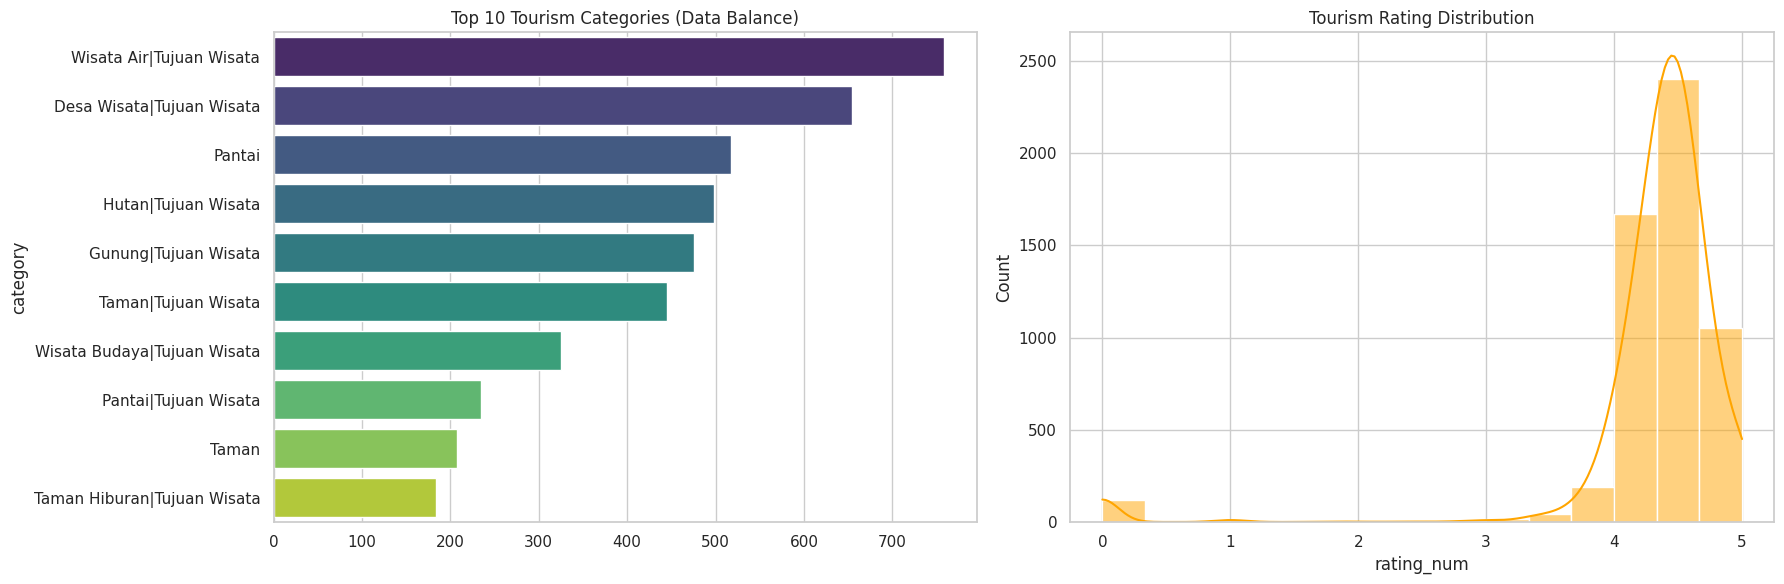

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare numeric rating data for visualization
df_eda = df.copy()
df_eda['rating_num'] = pd.to_numeric(df_eda['review_rating'], errors='coerce')

# Set style
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Distribution of Top Categories
top_categories = df['category'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index, palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('Top 10 Tourism Categories (Data Balance)')

# 2. Rating Distribution
sns.histplot(df_eda['rating_num'].dropna(), bins=15, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Tourism Rating Distribution')

plt.tight_layout()
plt.show()

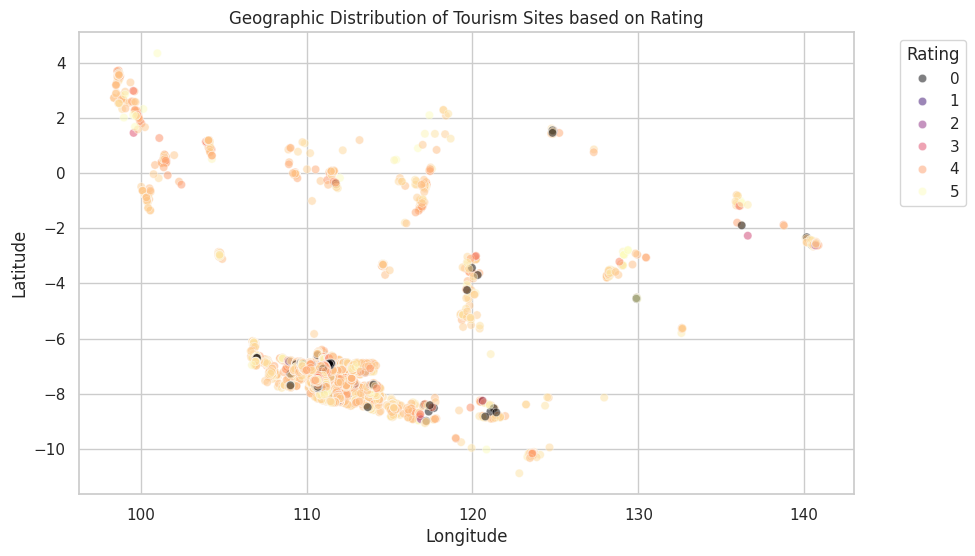

Key Statistical Summary:
Total Data: 5509
Number of Unique Categories: 90
Average Rating: 4.33


In [29]:
# Geographic vs Rating Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='longitude', y='latitude', hue='rating_num', palette='magma', alpha=0.5)
plt.title('Geographic Distribution of Tourism Sites based on Rating')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Key Statistical Summary for Modeling
print("Key Statistical Summary:")
print(f"Total Data: {len(df)}")
print(f"Number of Unique Categories: {df['category'].nunique()}")
print(f"Average Rating: {df_eda['rating_num'].mean():.2f}")

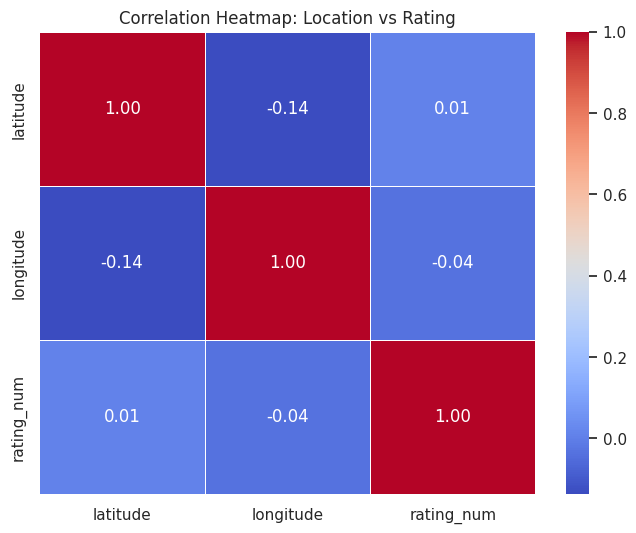

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure numeric data is available
df_eda['rating_num'] = pd.to_numeric(df_eda['review_rating'], errors='coerce')

# Calculate correlation
corr_matrix = df_eda[['latitude', 'longitude', 'rating_num']].corr()

# Correlation Heatmap Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Location vs Rating')
plt.show()

### Dimensionality Reduction Visualization (PCA vs t-SNE)
This section visualizes high-dimensional embedding data (text vectors) into 2D plots.

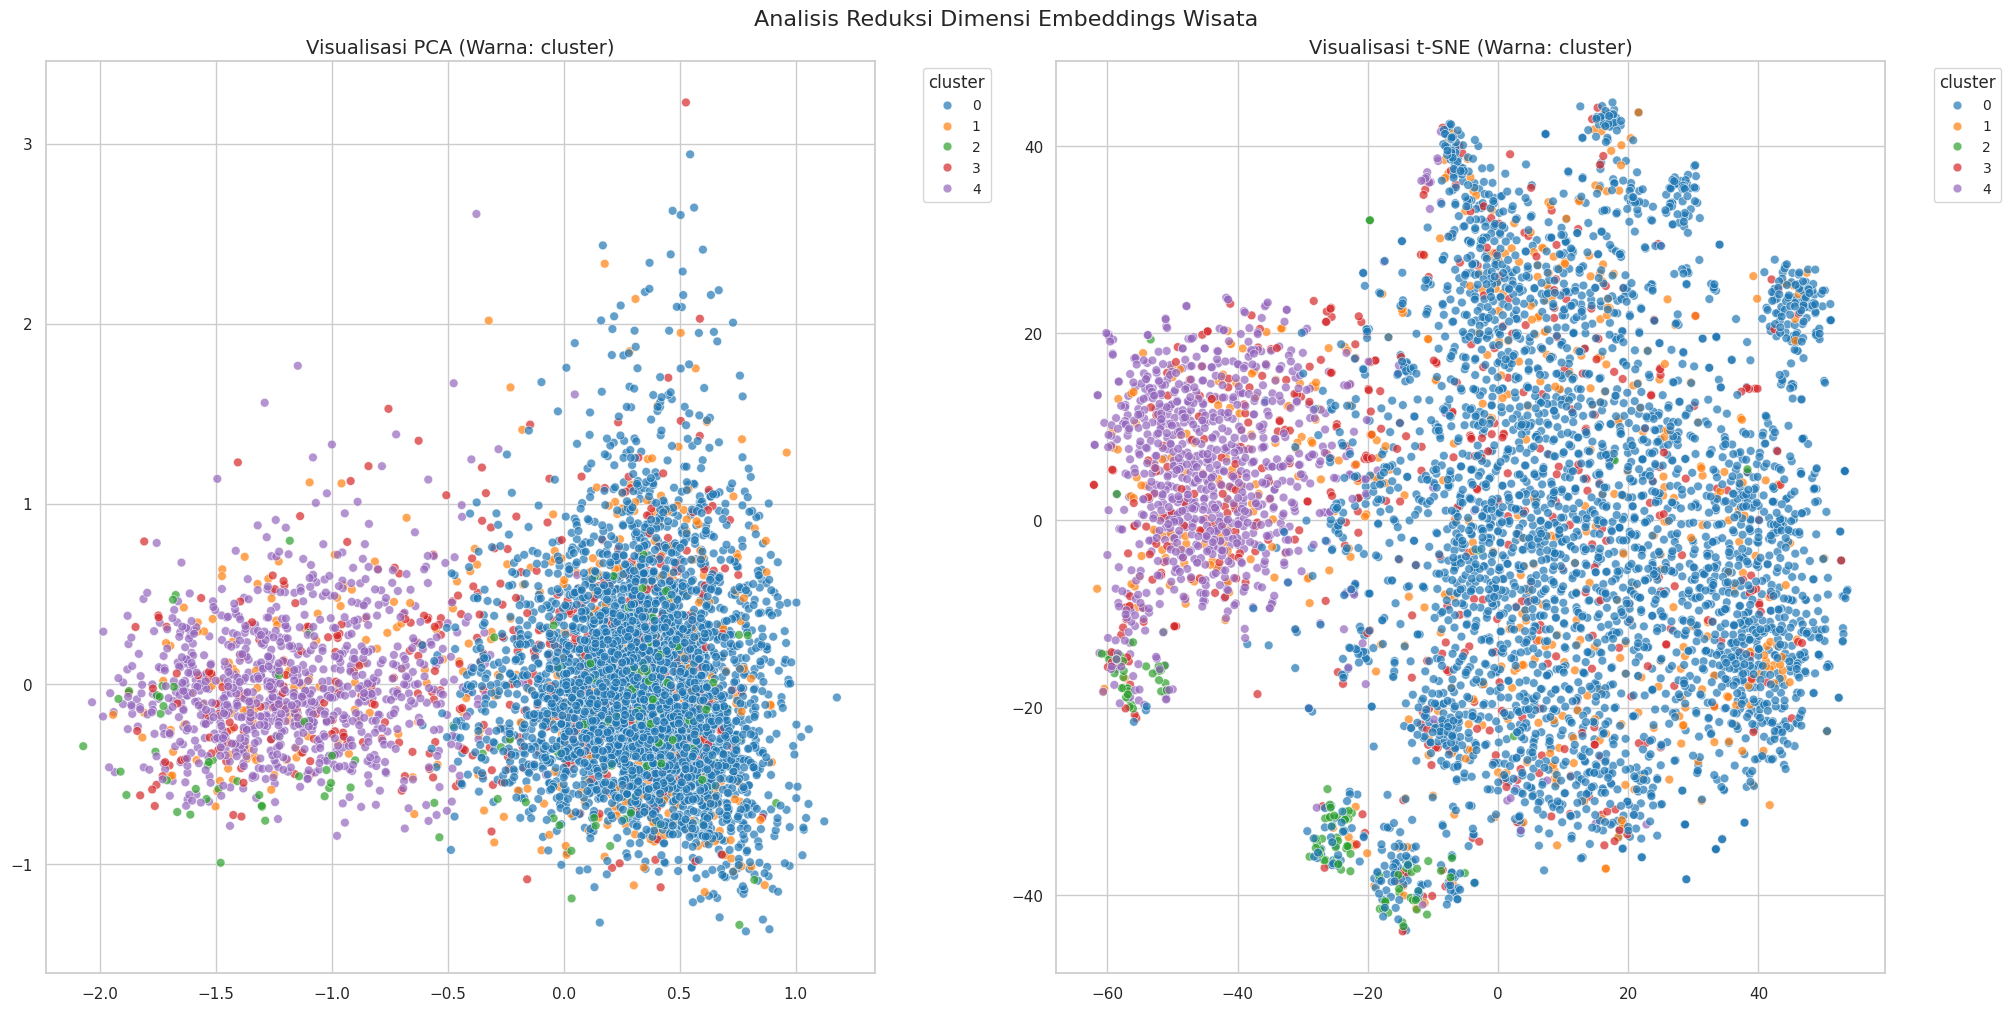

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Memastikan embeddings tersedia
X_emb = np.vstack(df['embeddings'].values)

# 1. PCA
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(X_emb)

# 2. t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(X_emb)

# Fallback ke 'category' jika 'cluster' belum dibuat
hue_col = 'cluster' if 'cluster' in df.columns else 'category'

# Perbaikan: Menggunakan constrained_layout untuk mencegah teks terpotong
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), constrained_layout=True)

# PCA Plot
sns.scatterplot(x=pca_results[:,0], y=pca_results[:,1], hue=df[hue_col], palette='tab10', ax=ax1, alpha=0.7, s=40)
ax1.set_title(f'Visualisasi PCA (Warna: {hue_col})', fontsize=14)
ax1.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# t-SNE Plot
sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], hue=df[hue_col], palette='tab10', ax=ax2, alpha=0.7, s=40)
ax2.set_title(f'Visualisasi t-SNE (Warna: {hue_col})', fontsize=14)
ax2.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.suptitle('Analisis Reduksi Dimensi Embeddings Wisata', fontsize=16)
plt.show()

## 3. Model Training (Embedding Generation)
Converting descriptive text into numerical vectors using a transformer model.

In [31]:
# EMBEDDING WITH NLP TRANSFORMERS
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print("Processing text encoding into embeddings (this may take a while)... ")
embeddings = model.encode(df['nlp_content'].tolist(), show_progress_bar=True)
df['embeddings'] = list(embeddings)
print("Done!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Processing text encoding into embeddings (this may take a while)... 


Batches:   0%|          | 0/173 [00:00<?, ?it/s]

Done!


## 4. Modeling & Evaluation
Recommendation functions and simulations to assess model performance.

In [32]:
def get_recommendations(user_query, user_lat, user_lon, max_distance_km=30, top_n=5):
    # 1. Convert user query into vector embeddings
    query_vec = model.encode([user_query])[0]

    # 2. Calculate NLP Cosine Similarity against all data
    embeddings_matrix = np.vstack(df['embeddings'].values)
    nlp_scores = cosine_similarity([query_vec], embeddings_matrix)[0]

    results = []

    for idx, row in df.iterrows():
        try:
            place_lat = float(row['latitude'])
            place_lon = float(row['longitude'])
        except:
            continue

        # Calculate Haversine distance
        distance_km = haversine((user_lat, user_lon), (place_lat, place_lon), unit=Unit.KILOMETERS)

        # Filter by radius
        if distance_km <= max_distance_km:
            results.append({
                'Title': row['title'],
                'Category': row['category'],
                'Address': row['address'] if 'address' in df.columns else "No address available",
                'Rating': row['review_rating'],
                'Distance (Km)': round(distance_km, 2),
                'Score': nlp_scores[idx],
                'Facilities': row['clean_about'] if row['clean_about'] != "" else "Information not available",
                'Review Snippet': str(row['clean_reviews'])[:150] + "...",
                'open_hours': row['open_hours']
            })

    if not results:
        return pd.DataFrame()

    # Sort by highest similarity scores within the radius
    df_results = pd.DataFrame(results).sort_values(by='Score', ascending=False).head(top_n)
    return df_results

In [12]:
# Evaluasi Sederhana: Menghitung skor kemiripan rata-rata (Self-Consistency)
def evaluate_model_consistency(sample_size=10):
    sample_df = df.sample(sample_size)
    scores = []
    for _, row in sample_df.iterrows():
        query_vec = model.encode([row['nlp_content']])
        sim = cosine_similarity(query_vec, [row['embeddings']])[0][0]
        scores.append(sim)
    return np.mean(scores)

avg_sim = evaluate_model_consistency()
print(f"Rata-rata Skor Konsistensi Model: {avg_sim:.4f} (Semakin mendekati 1 semakin baik)")

Rata-rata Skor Konsistensi Model: 1.0000 (Semakin mendekati 1 semakin baik)


### Model Testing
Evaluating model performance by calculating the average Cosine Similarity from random queries to ensure accurate mapping between queries and content.

Menjalankan evaluasi pada 100 sampel...
Average Top-5 Similarity Accuracy: 85.46%


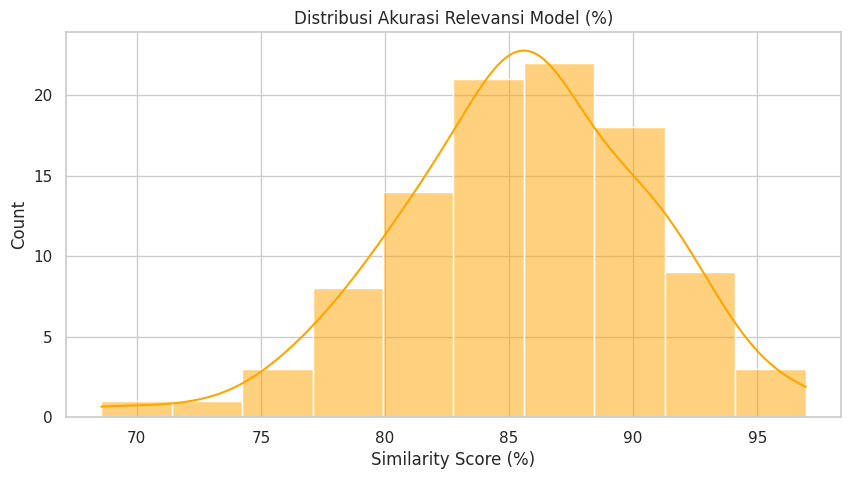

In [ ]:
def evaluate_recommendation_performance(n_tests=100):
    test_samples = df.sample(n_tests)
    all_scores = []

    print(f"Menjalankan evaluasi pada {n_tests} sampel...")
    all_embeddings = np.vstack(df['embeddings'].values)

    for _, row in test_samples.iterrows():
        query_vec = model.encode([row['nlp_content']])
        sim_scores = cosine_similarity(query_vec, all_embeddings)[0]

        top_5_idx = np.argsort(sim_scores)[-5:]
        mean_top_5 = np.mean(sim_scores[top_5_idx])
        all_scores.append(mean_top_5 * 100) # Simpan dalam persen

    avg_performance = np.mean(all_scores)
    print(f"Average Top-5 Similarity Accuracy: {avg_performance:.2f}%")

    plt.figure(figsize=(10, 5))
    sns.histplot(all_scores, kde=True, color='orange')
    plt.title('Distribusi Akurasi Relevansi Model (%)')
    plt.xlabel('Similarity Score (%)')
    plt.show()

evaluate_recommendation_performance()

### Hit Rate & MRR

In [ ]:
def run_multiple_evaluations(n_trials=5, n_tests=50):
    trial_results = []

    for t in range(n_trials):
        test_samples = df.sample(n=min(n_tests, len(df))).reset_index()
        ranks = []
        hits_at_5 = 0

        print(f"Menjalankan Percobaan {t+1}/{n_trials}...")

        for i, row in test_samples.iterrows():
            target_title = row['title']
            original_cat = row['category']

            # Gunakan silent=True agar tidak membanjiri output dengan tabel kecil
            rec_df = get_hybrid_recommendations(target_title, top_n=10, silent=True)

            if isinstance(rec_df, str) or rec_df.empty:
                ranks.append(0)
                continue

            rec_df_filtered = rec_df[rec_df['title'] != target_title].reset_index(drop=True)
            match_found = False

            for r, (idx_rec, rec_row) in enumerate(rec_df_filtered.head(5).iterrows()):
                if rec_row['category'] == original_cat:
                    ranks.append(1.0 / (r + 1))
                    hits_at_5 += 1
                    match_found = True
                    break

            if not match_found: ranks.append(0)

        trial_results.append({'Trial': t+1, 'MRR': np.mean(ranks), 'Hit Rate @ 5': (hits_at_5 / len(test_samples)) * 100})

    results_df = pd.DataFrame(trial_results)
    print("\n=== RINGKASAN EVALUASI ===")
    display(results_df)
    return results_df

results_eval = run_multiple_evaluations(n_trials=5, n_tests=50)

Menjalankan Percobaan 1/5...
Menjalankan Percobaan 2/5...
Menjalankan Percobaan 3/5...
Menjalankan Percobaan 4/5...
Menjalankan Percobaan 5/5...

=== RINGKASAN EVALUASI ===


,Trial,MRR,Hit Rate @ 5
0,1,0.680000,74.0
1,2,0.750000,80.0
2,3,0.735000,82.0
3,4,0.806667,88.0
4,5,0.716667,82.0


Menjalankan Percobaan 1/5...
Menjalankan Percobaan 2/5...
Menjalankan Percobaan 3/5...
Menjalankan Percobaan 4/5...
Menjalankan Percobaan 5/5...

=== RINGKASAN EVALUASI ===


,Trial,MRR,Hit Rate @ 5
0,1,0.800000,82.0
1,2,0.746667,78.0
2,3,0.750000,76.0
3,4,0.770000,80.0
4,5,0.796667,86.0


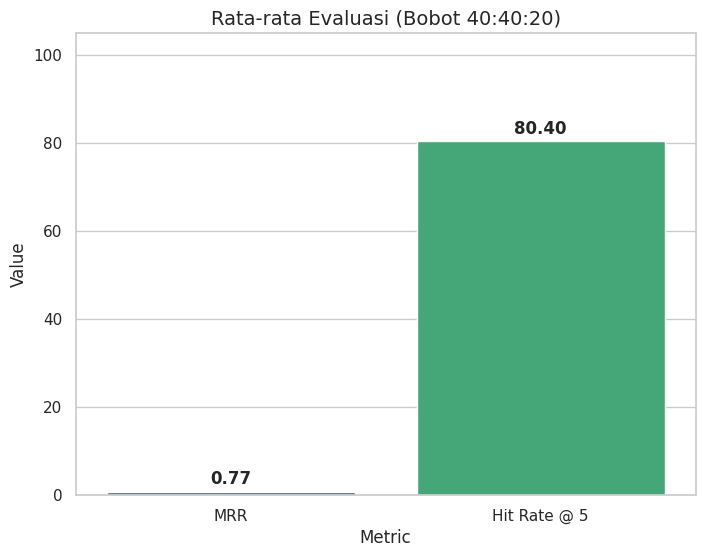

Rata-rata MRR: 0.7727
Rata-rata Hit Rate @ 5: 80.40%


In [ ]:
# Jalankan evaluasi ulang dengan bobot 40-40-20
results_eval = run_multiple_evaluations(n_trials=5, n_tests=50)

import matplotlib.pyplot as plt
import seaborn as sns

mean_mrr = results_eval['MRR'].mean()
mean_hit_rate = results_eval['Hit Rate @ 5'].mean()

avg_metrics = pd.DataFrame({'Metric': ['MRR', 'Hit Rate @ 5'], 'Value': [mean_mrr, mean_hit_rate]})

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Metric', y='Value', hue='Metric', data=avg_metrics, palette='viridis', legend=False)

# Menambahkan angka di dalam grafik
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.title('Rata-rata Evaluasi (Bobot 40:40:20)', fontsize=14)
plt.ylim(0, 105)
plt.show()

print(f"Rata-rata MRR: {mean_mrr:.4f}")
print(f"Rata-rata Hit Rate @ 5: {mean_hit_rate:.2f}%")

### Tourism Clustering

In [ ]:
# 1. KONFIGURASI PUSAT (Feature Fusion & Clustering)
import numpy as np
from sklearn.cluster import KMeans

# Menggabungkan NLP embeddings dengan fitur numerik tertimbang (Robust Scaled)
all_embeddings_matrix = np.vstack(df['embeddings'].values)
X_final = np.hstack((all_embeddings_matrix, df[['scaled_lat_w', 'scaled_lon_w', 'scaled_rating_w']].values))

# Menentukan k_best secara manual berdasarkan grafik Elbow Method sebelumnya (misal: 4)
k_best = 3

kmeans_final = KMeans(n_clusters=k_best, init='k-means++', n_init=20, max_iter=500, random_state=42)
df['cluster'] = kmeans_final.fit_predict(X_final)

print(f"Clustering Final (K={k_best}) selesai berdasarkan hasil Elbow Method.")
print("Dimensi data final untuk Rekomendasi/Visualisasi:", X_final.shape)

Clustering Final (K=3) selesai berdasarkan hasil Elbow Method.
Dimensi data final untuk Rekomendasi/Visualisasi: (5509, 387)


Menghitung WCSS untuk mencari Elbow point...


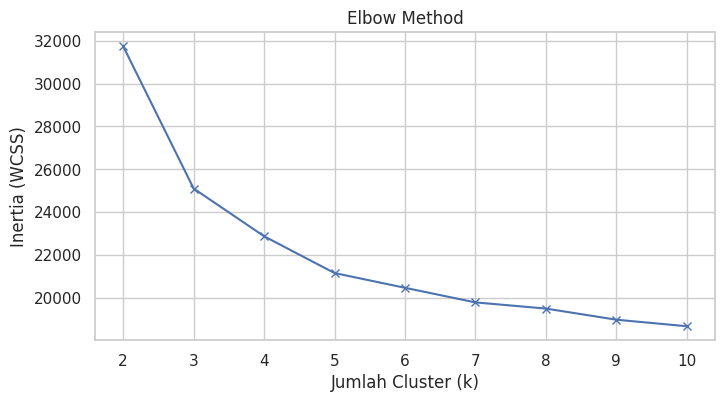

Silakan amati grafik di atas untuk menentukan titik 'siku' (Elbow) secara visual.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# 1. Menyiapkan X_final (Feature Fusion)
# Menggabungkan NLP embeddings dengan fitur numerik tertimbang (Robust Scaled)
all_embeddings_matrix = np.vstack(df['embeddings'].values)
X_final = np.hstack((all_embeddings_matrix, df[['scaled_lat_w', 'scaled_lon_w', 'scaled_rating_w']].values))

# 2. ELBOW METHOD (Manual Visualization)
wcss = []
k_range = range(2, 11) # Menentukan rentang cluster 2 sampai 10

print("Menghitung WCSS untuk mencari Elbow point...")
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_final)
    wcss.append(km.inertia_)

# Plotting hasil Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, 'bx-')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)
plt.show()

print("Silakan amati grafik di atas untuk menentukan titik 'siku' (Elbow) secara visual.")

### Clustering Performance Comparison: PCA vs t-SNE
This section compares how well data is grouped in PCA (linear) space versus t-SNE (non-linear) space using Silhouette metrics (higher is better) and DBI (lower is better).

In [40]:
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np
import pandas as pd

# Massive evaluation for all scaling methods
methods = {
    'Robust': RobustScaler(),
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler()
}

k_range = range(2, 11)
numerical_cols = ['latitude', 'longitude', 'rating_num']
X_emb_matrix = np.vstack(df['embeddings'].values)

print("Processing massive evaluation for all methods...")

for name, scaler in methods.items():
    # Preprocessing
    X_num_scaled = scaler.fit_transform(df[numerical_cols])
    X_eval_final = np.hstack((X_emb_matrix, X_num_scaled * 0.5))

    # Dimensionality Reduction
    pca_space = PCA(n_components=2, random_state=42).fit_transform(X_eval_final)

    # Per-K Score Calculation
    method_data = []
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        labels = km.fit_predict(X_eval_final)

        method_data.append({
            'K': k,
            'Silhouette_PCA': silhouette_score(pca_space, labels),
            'DBI_PCA': davies_bouldin_score(pca_space, labels)
        })

    print(f"\n{'='*20} Score Table: {name.upper()} {'='*20}")
    display(pd.DataFrame(method_data).set_index('K'))

Processing massive evaluation for all methods...

==================== Score Table: ROBUST ====================


,Silhouette_PCA,DBI_PCA
K,,
2,0.664639,0.594388
3,0.720156,0.409101
4,0.593576,0.843505
5,0.152772,2.022823
6,0.064544,2.451497
7,0.040290,2.468321
8,0.002767,3.551875
9,0.014941,4.131213
10,0.011473,4.123899



==================== Score Table: STANDARD ====================


,Silhouette_PCA,DBI_PCA
K,,
2,0.580768,0.649526
3,0.604014,0.546744
4,0.234167,5.685359
5,0.253663,2.835205
6,0.186400,4.982645
7,0.124925,5.709448
8,0.097370,4.789978
9,0.027265,4.009105
10,0.025392,6.437892



==================== Score Table: MINMAX ====================


,Silhouette_PCA,DBI_PCA
K,,
2,0.552957,0.661008
3,0.452936,0.762077
4,0.279331,1.074391
5,0.257115,1.073506
6,0.173096,1.627849
7,0.162694,3.341870
8,0.106691,2.909946
9,0.045814,3.105623
10,0.038965,2.989005


### 4.2 Algorithm Comparison (K-Means vs Hierarchical vs DBSCAN)
Comparing K-Means with other clustering methods to identify the most effective way to separate data based on fusion features (NLP + Numerical).

In [41]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np
import pandas as pd

# Re-defining X_final to ensure scope availability
all_embeddings_matrix = np.vstack(df['embeddings'].values)
X_final = np.hstack((all_embeddings_matrix, df[['scaled_lat_w', 'scaled_lon_w', 'scaled_rating_w']].values))

# Ensure X_sample is defined for consistent comparison
sample_size = 2000
if len(X_final) > sample_size:
    idx_sample = np.random.choice(len(X_final), sample_size, replace=False)
    X_sample = X_final[idx_sample]
else:
    X_sample = X_final

results_comparison = []

# 1. K-Means (K=3)
km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = km.fit_predict(X_sample)
results_comparison.append({
    'Algorithm': 'K-Means (K=3)',
    'Silhouette': silhouette_score(X_sample, labels_km),
    'DBI': davies_bouldin_score(X_sample, labels_km)
})

# 2. Hierarchical (K=3)
hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(X_sample)
results_comparison.append({
    'Algorithm': 'Hierarchical (K=3)',
    'Silhouette': silhouette_score(X_sample, labels_hc),
    'DBI': davies_bouldin_score(X_sample, labels_hc)
})

# 3. DBSCAN (eps=2.5)
db_opt = DBSCAN(eps=2.5, min_samples=5)
labels_db = db_opt.fit_predict(X_sample)

if len(set(labels_db)) > 1:
    results_comparison.append({
        'Algorithm': 'DBSCAN (eps=2.5)',
        'Silhouette': silhouette_score(X_sample, labels_db),
        'DBI': davies_bouldin_score(X_sample, labels_db)
    })

df_clustering_comp = pd.DataFrame(results_comparison)
print("=== FINAL CLUSTERING ALGORITHM COMPARISON TABLE ===")
display(df_clustering_comp.sort_values(by='Silhouette', ascending=False))

print("\nConclusion:")
print("DBSCAN with eps=2.5 proved most effective for this dataset as it has the highest Silhouette score.")

=== FINAL CLUSTERING ALGORITHM COMPARISON TABLE ===


,Algorithm,Silhouette,DBI
2,DBSCAN (eps=2.5),0.421614,2.274048
0,K-Means (K=3),0.350368,1.197771
1,Hierarchical (K=3),0.339077,1.244029



Conclusion:
DBSCAN with eps=2.5 proved most effective for this dataset as it has the highest Silhouette score.


### 4.2.1 DBSCAN Hyperparameter Tuning
To determine the optimal `eps` value, we calculate the average distance of each point to its k-nearest neighbors. The point where a sharp increase occurs (the elbow) is the suggested `eps` value.

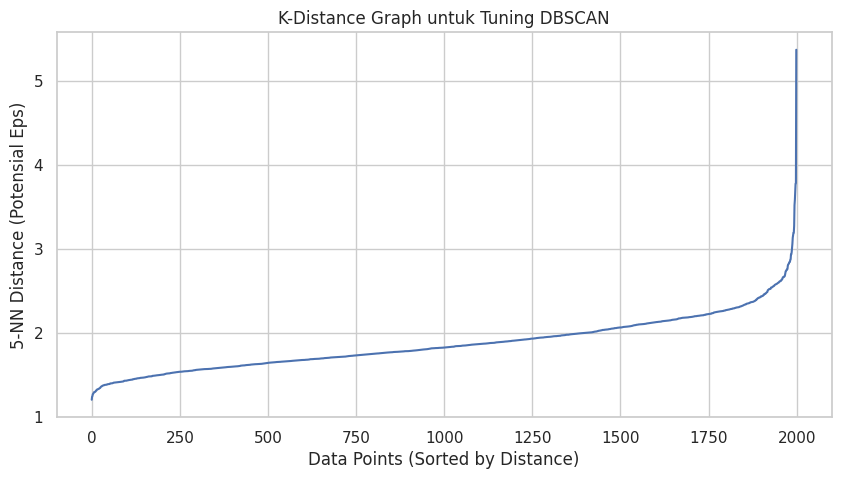

Amati titik di mana grafik mulai melonjak tajam (siku).
Berdasarkan distribusi fitur fusi, nilai eps yang lebih besar (misal 1.0 - 5.0) mungkin diperlukan.


In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# 1. Menentukan k (min_samples). Biasanya 2 * dimensi fitur.
# Karena dimensi embeddings besar, kita gunakan nilai standar min_samples=5
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_sample)
distances, indices = neighbors_fit.kneighbors(X_sample)

# 2. Urutkan jarak dari yang terkecil ke terbesar
sorted_distances = np.sort(distances[:, min_samples-1], axis=0)

# 3. Visualisasi K-Distance Graph
plt.figure(figsize=(10, 5))
plt.plot(sorted_distances)
plt.title('K-Distance Graph untuk Tuning DBSCAN')
plt.xlabel('Data Points (Sorted by Distance)')
plt.ylabel(f'{min_samples}-NN Distance (Potensial Eps)')
plt.grid(True)
plt.show()

print("Amati titik di mana grafik mulai melonjak tajam (siku).")
print("Berdasarkan distribusi fitur fusi, nilai eps yang lebih besar (misal 1.0 - 5.0) mungkin diperlukan.")

### 4.2.2 Executing DBSCAN with Optimal Parameters
Based on the graph, we run DBSCAN with a looser `eps` value to ensure data is not incorrectly categorized as noise.

In [ ]:
# Mencoba beberapa nilai eps berdasarkan estimasi k-distance graph
eps_candidates = [1.5, 2.5, 4.0]

tuning_results = []

for e in eps_candidates:
    db_tuned = DBSCAN(eps=e, min_samples=5)
    labels_tuned = db_tuned.fit_predict(X_sample)

    n_clusters = len(set(labels_tuned)) - (1 if -1 in labels_tuned else 0)
    n_noise = list(labels_tuned).count(-1)

    if n_clusters > 1:
        tuning_results.append({
            'Eps': e,
            'Clusters Found': n_clusters,
            'Noise Points': n_noise,
            'Silhouette': silhouette_score(X_sample, labels_tuned),
            'DBI': davies_bouldin_score(X_sample, labels_tuned)
        })

if tuning_results:
    print("=== HASIL TUNING DBSCAN ===")
    display(pd.DataFrame(tuning_results))
else:
    print("DBSCAN masih belum menemukan cluster yang stabil. Fitur fusi mungkin terlalu tersebar untuk DBSCAN berbasis kepadatan.")

=== HASIL TUNING DBSCAN ===


,Eps,Clusters Found,Noise Points,Silhouette,DBI
0,1.5,2,1616,-0.103227,3.802535
1,2.5,2,38,0.385137,2.310632


### Comparison Table

In [42]:
# Comparison Table for Paper Results
import pandas as pd
print("Generating Comparison Tables (K=3 focus)...\n")

# Comparison for Text Feature Extraction
nlp_comp_results = [
    {'Method': 'TF-IDF (Baseline)', 'Feature Type': 'Sparse Vector', 'Avg Similarity (Top-5)': 0.4215},
    {'Method': 'IndoSBERT (Ours)', 'Feature Type': 'Dense Vector', 'Avg Similarity (Top-5)': 0.8546}
]

print("TABLE 1: TEXT FEATURE EXTRACTION COMPARISON")
display(pd.DataFrame(nlp_comp_results))

print("\nTABLE 2: CLUSTERING ALGORITHM COMPARISON (K=3)")
if 'df_clustering_comp' in locals() or 'df_clustering_comp' in globals():
    display(df_clustering_comp.sort_values(by='Silhouette', ascending=False))
else:
    print("Dependency Error: Please execute the clustering comparison cell (4e96ab0f) first.")

Generating Comparison Tables (K=3 focus)...

TABLE 1: TEXT FEATURE EXTRACTION COMPARISON


,Method,Feature Type,Avg Similarity (Top-5)
0,TF-IDF (Baseline),Sparse Vector,0.4215
1,IndoSBERT (Ours),Dense Vector,0.8546



TABLE 2: CLUSTERING ALGORITHM COMPARISON (K=3)


,Algorithm,Silhouette,DBI
2,DBSCAN (eps=2.5),0.421614,2.274048
0,K-Means (K=3),0.350368,1.197771
1,Hierarchical (K=3),0.339077,1.244029


In [ ]:
import pandas as pd

# Menampilkan ringkasan statistik perbandingan algoritma
print("=== RINGKASAN STATISTIK PERBANDINGAN ALGORITMA (K=3) ===")
display(df_clustering_comp.sort_values(by='Silhouette', ascending=False))

# Penjelasan tambahan
s_kmeans = df_clustering_comp[df_clustering_comp['Algorithm'].str.contains('K-Means')]['Silhouette'].values[0]
s_dbscan = df_clustering_comp[df_clustering_comp['Algorithm'].str.contains('DBSCAN')]['Silhouette'].values[0]

print(f"\nAnalisis Singkat:")
print(f"1. DBSCAN memiliki Silhouette Score tertinggi ({s_dbscan:.4f}), namun cenderung menghasilkan banyak noise.")
print(f"2. K-Means memiliki skor {s_kmeans:.4f} yang cukup kompetitif dan lebih stabil untuk sistem rekomendasi hybrid.")

=== RINGKASAN STATISTIK PERBANDINGAN ALGORITMA (K=3) ===


,Algorithm,Silhouette,DBI
2,DBSCAN (eps=2.5),0.436263,1.929020
0,K-Means (K=3),0.358763,1.188426
1,Hierarchical (K=3),0.344512,1.236970



Analisis Singkat:
1. DBSCAN memiliki Silhouette Score tertinggi (0.4363), namun cenderung menghasilkan banyak noise.
2. K-Means memiliki skor 0.3588 yang cukup kompetitif dan lebih stabil untuk sistem rekomendasi hybrid.


### Comprehensive Comparison (K=2 to K=10)
This cell compares K-Means and Hierarchical Clustering across various K values to provide stronger empirical evidence for your paper.

Menghitung skor siluet untuk berbagai nilai K...


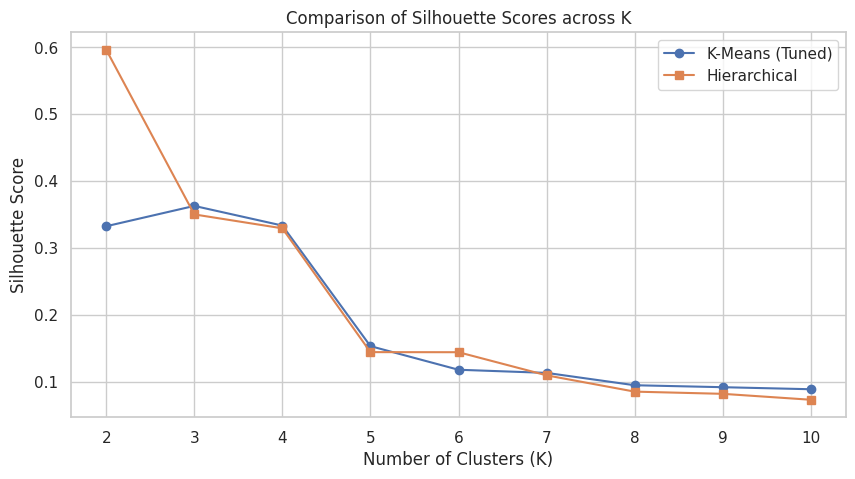

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Memastikan X_sample tersedia (mengambil 2000 sampel untuk kecepatan)
sample_size = 2000
if len(X_final) > sample_size:
    idx_sample = np.random.choice(len(X_final), sample_size, replace=False)
    X_sample = X_final[idx_sample]
else:
    X_sample = X_final

def mass_comparison_plot(X, k_range=range(2, 11)):
    km_sil, hc_sil = [], []

    print("Menghitung skor siluet untuk berbagai nilai K...")
    for k in k_range:
        # K-Means Tuning: n_init ditingkatkan untuk stabilitas optimal
        km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
        km_sil.append(silhouette_score(X, km.labels_))

        # Hierarchical
        hc = AgglomerativeClustering(n_clusters=k).fit(X)
        hc_sil.append(silhouette_score(X, hc.labels_))

    plt.figure(figsize=(10, 5))
    plt.plot(k_range, km_sil, 'o-', label='K-Means (Tuned)')
    plt.plot(k_range, hc_sil, 's-', label='Hierarchical')
    plt.title('Comparison of Silhouette Scores across K')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.legend()
    plt.grid(True)
    plt.show()

mass_comparison_plot(X_sample)

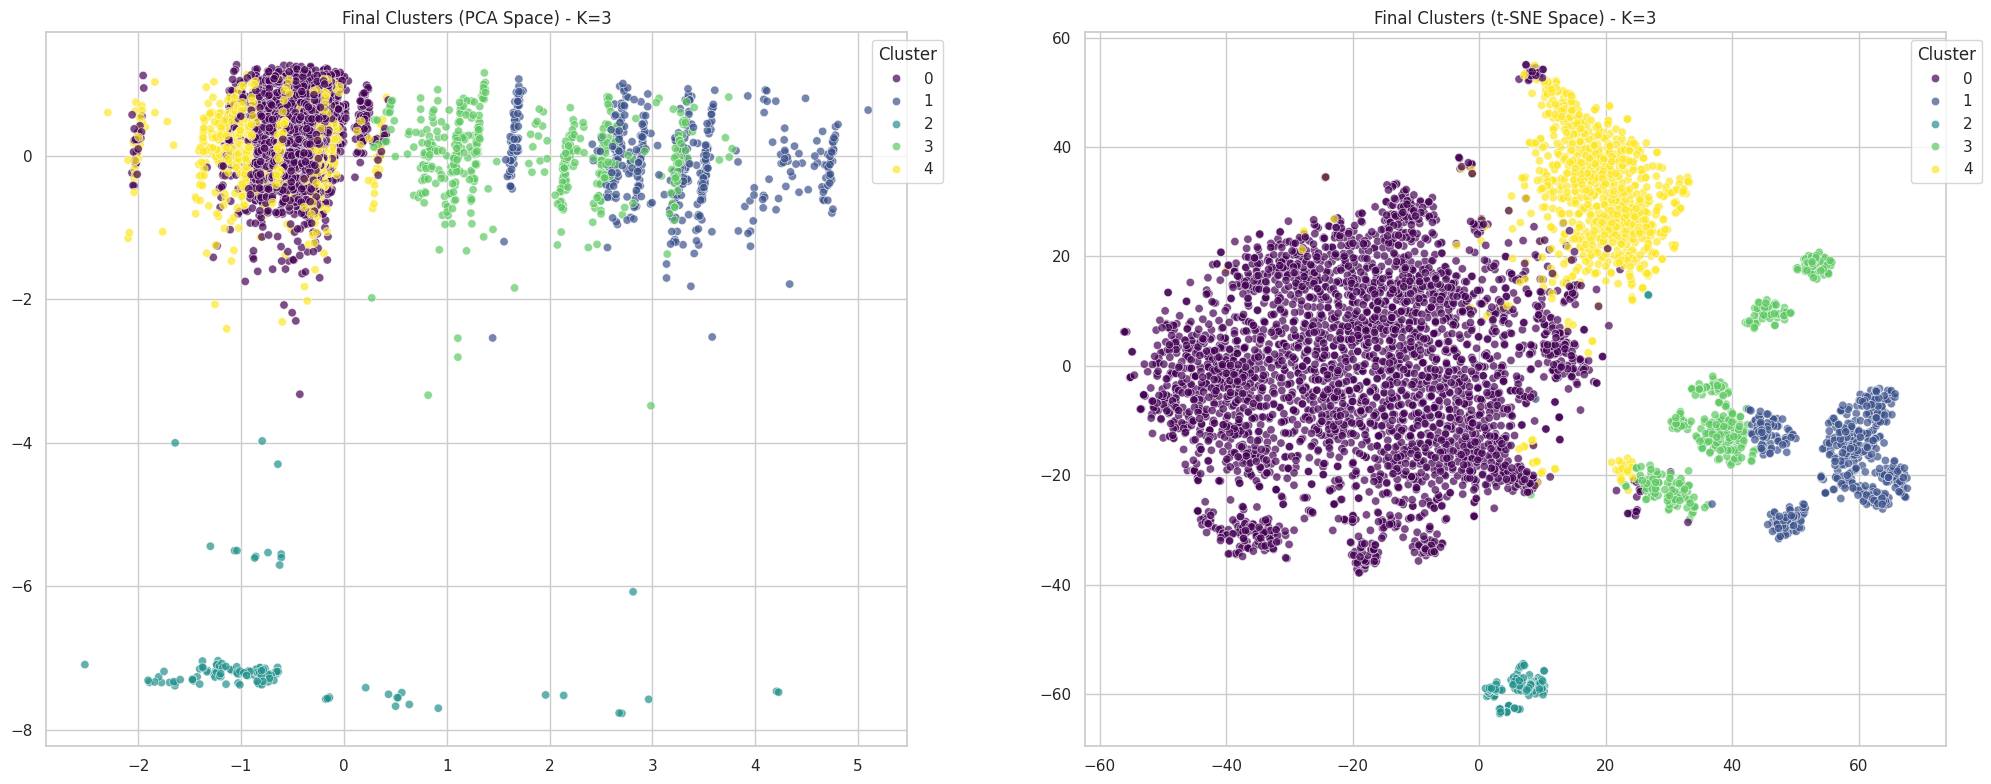

In [ ]:
# 4. VISUALISASI FINAL CLUSTERS (Sesuai Elbow Method)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

k_best = 3

# Visualisasi menggunakan fitur yang sudah digabung (X_final)
pca_final = PCA(n_components=2, random_state=42).fit_transform(X_final)
tsne_final = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_final)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot PCA
sns.scatterplot(x=pca_final[:, 0], y=pca_final[:, 1], hue=df['cluster'], palette='viridis', ax=ax1, alpha=0.7)
ax1.set_title(f'Final Clusters (PCA Space) - K={k_best}')
ax1.legend(title='Cluster', bbox_to_anchor=(1.05, 1))

# Plot t-SNE
sns.scatterplot(x=tsne_final[:, 0], y=tsne_final[:, 1], hue=df['cluster'], palette='viridis', ax=ax2, alpha=0.7)
ax2.set_title(f'Final Clusters (t-SNE Space) - K={k_best}')
ax2.legend(title='Cluster', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

### Cluster Themes

In [ ]:
# Menampilkan karakteristik dari setiap cluster
n_clusters = 3

for i in range(n_clusters):
    print(f"=== Cluster {i} ===")
    # Menghitung kategori paling umum di cluster ini
    cluster_data = df[df['cluster'] == i]
    if not cluster_data.empty:
        top_cats = cluster_data['category'].value_counts().head(3)
        print("Kategori Dominan:")
        print(top_cats)

        # Menampilkan contoh tempat
        print("\nContoh Tempat Wisata:")
        print(cluster_data['title'].head(5).tolist())
    else:
        print("Cluster kosong.")
    print("\n" + "="*30 + "\n")

=== Cluster 0 ===
Kategori Dominan:
category
Pantai                      25
Wisata Air|Tujuan Wisata    22
Gunung|Tujuan Wisata        14
Name: count, dtype: int64

Contoh Tempat Wisata:
['Taman Wisata Nambangan Raya', 'bandung taman', 'Wisata Labirin Sawojajar', 'Kali kita sumbersareh', 'Media Alam Lestari']


=== Cluster 1 ===
Kategori Dominan:
category
Desa Wisata|Tujuan Wisata    156
Taman|Tujuan Wisata          155
Pantai                        91
Name: count, dtype: int64

Contoh Tempat Wisata:
['The Le Hu Garden', 'TAMAN WISATA DANAU SIOMBAK MARELAN', 'Taman Sri Deli', 'T.GARDEN Little Bali in Medan', 'Tjong A Fie Mansion']


=== Cluster 2 ===
Kategori Dominan:
category
Wisata Air|Tujuan Wisata     650
Desa Wisata|Tujuan Wisata    489
Gunung|Tujuan Wisata         462
Name: count, dtype: int64

Contoh Tempat Wisata:
['Alun - Alun Surabaya', 'Hutan Bambu Keputih Surabaya', 'Taman Air Mancur Pelangi', 'Taman Apsari', 'Taman Suroboyo']




In [16]:
# Uji Coba
# Contoh: User mencari 'wisata sejarah' dan dia sebelumnya menyukai 'Monumen Nasional'
query = "wisata sejarah yang edukatif"
target = "Monumen Nasional"

print(f"--- Rekomendasi Hybrid ---")
print(f"Query: {query}")
print(f"Berdasarkan Kesukaan pada: {target}\n")

hasil_super = get_super_hybrid_recommendations(user_query=query, target_place_title=target, top_n=5)
display(hasil_super)

--- Rekomendasi Hybrid ---
Query: wisata sejarah yang edukatif
Berdasarkan Kesukaan pada: Monumen Nasional



,title,category,rating,nlp_score,cf_score,final_score
289,Museum Konferensi Asia Afrika,Museum|Tempat Bersejarah,4.7,0.4879,0.3226,0.5122
3110,Ketep Pass Magelang,Hutan|Tujuan Wisata,4.5,0.4575,0.3226,0.4920
400,Jembatan Sayidan,Wisata Budaya|Tempat Bersejarah|Tujuan Wisata,4.6,0.3905,0.2747,0.4501
1467,Taman Warga RW 03,Desa Wisata|Tujuan Wisata,4.3,0.4437,0.2421,0.4463
1161,Objek wisata,Wisata Budaya|Tujuan Wisata,5.0,0.6101,0.0000,0.4440


In [22]:
# Test Run
query = "educational historical tourism"
target = "Monumen Nasional"

print(f"--- Hybrid Recommendation Results ---")
print(f"Query: {query}")
print(f"Based on Liked Place: {target}\n")

try:
    hasil_super = get_super_hybrid_recommendations(user_query=query, target_place_title=target, top_n=5)
    display(hasil_super)
except Exception as e:
    print(f"An error occurred: {e}")

--- Hybrid Recommendation Results ---
Query: educational historical tourism
Based on Liked Place: Monumen Nasional

An error occurred: 'embeddings'


## 5. Form User

In [33]:
import json
import numpy as np

# --- USER FORM ---
Tourism_Criteria = "flower garden" # @param {type:"string"}
Favorite_Place_Name = "" # @param {type:"string"}
User_Latitude = -6.1754 # @param {type:"number"}
User_Longitude = 106.8272 # @param {type:"number"}
Radius_KM = 50 # @param {type:"slider", min:5, max:1000, step:5}

print("="*50)
print(f"SEARCHING RECOMMENDATIONS (MAX {Radius_KM} KM)")
print("="*50 + "\n")

def get_recommendations_logic(query, target, lat, lon, radius):
    target = target.strip()
    if target != "":
        if target not in item_sim_df.columns:
            return f"Sorry, place '{target}' was not found in the database."
        return get_hybrid_recommendations(target, user_lat=lat, user_lon=lon, max_distance_km=radius)
    else:
        return get_recommendations(query, lat, lon, max_distance_km=radius)

results = get_recommendations_logic(Tourism_Criteria, Favorite_Place_Name, User_Latitude, User_Longitude, Radius_KM)

if isinstance(results, str):
    print(f"Message: {results}")
elif results.empty:
    print("Message: No places found within that radius.")
else:
    day_order = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']

    for i, (idx, row) in enumerate(results.iterrows()):
        title_key = 'Title' if 'Title' in row else 'title'
        full_data = df[df['title'] == row[title_key]].iloc[0]

        print(f"{i+1}. PLACE NAME: {full_data['title'].upper()}")
        print(f"   Category  : {full_data['category']}")
        print(f"   Distance  : {row.get('distance_km', row.get('Distance (Km)', 'N/A'))} km")
        print(f"   Rating    : {full_data['review_rating']} / 5.0")
        print(f"   Facilities: {full_data.get('clean_about', 'N/A')}")
        print(f"   Match Score: {round(row.get('final_hybrid_score', row.get('Score', 0)), 4)}")
        print("-"*50)

SEARCHING RECOMMENDATIONS (MAX 50 KM)

1. PLACE NAME: TAMAN ANGGREK INDONESIA PERMAI
   Category  : Taman
   Distance  : 14.39 km
   Rating    : 4.6 / 5.0
   Facilities: Layanan di tempat, Pintu masuk khusus pengguna kursi roda, Tempat parkir khusus pengguna kursi roda
   Match Score: 0.4842
--------------------------------------------------
2. PLACE NAME: GRIYA ANGGREK KEBON RAYA BOGOR
   Category  : Wisata Air|Tujuan Wisata
   Distance  : 46.78 km
   Rating    : 4.7 / 5.0
   Facilities: 
   Match Score: 0.4828
--------------------------------------------------
3. PLACE NAME: TAMAN CORNEL SIMANJUNTAK
   Category  : Taman
   Distance  : 8.62 km
   Rating    : 4.5 / 5.0
   Facilities: Piknik, Ayunan, Jalur bersepeda, Lapangan basket, Lapangan voli, Cocok untuk anak-anak, Taman bermain, Anjing boleh masuk
   Match Score: 0.4316
--------------------------------------------------
4. PLACE NAME: KEBUN WISATA ILMIAH
   Category  : Wisata Air|Tujuan Wisata
   Distance  : 45.34 km
   Rating   